In [30]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

from matplotlib.pyplot import tight_layout
from statsmodels.sandbox.distributions.genpareto import meanexcess

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"
# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"

input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
        'leaf_hydraulic_capacitance', 'psi50_xylem', 'psi88_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0', 'jackson_root_beta',
        'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation', 'g_bark']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0', 'jackson_root_beta']
vars_soil = ['k_soil_sat0', 'psi_soil_sat0',
        'pore_0', 'root_area_index', 'wcont_sigma_deviation']

vars_all_ex = vars_all.copy()
vars_all_ex.append("RMSE_MAX")

vars_soil_ex = vars_soil.copy()
vars_soil_ex.append("RMSE_MAX")

df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
#index_to_drop = df[(df['sid']==2)|(df['sid']==3)].index
#df.drop(index_to_drop, inplace=True)
df = df[df['RMSE_MAX'] < 1.2]
df_grp = df.groupby(['id'])[vars_all_ex].mean()
dv = df[vars_all]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm = (dv - dv.mean()) / dv.std()
df_norm['sid'] = df['sid']
df_norm.shape

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_87819/1570480092.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])


(6160, 19)

In [31]:
vars_all

['psi_leaf_50_close',
 'd_50_close',
 'stem_hydraulic_capacitance',
 'k_xylem_sat',
 'huber_value',
 'leaf_hydraulic_capacitance',
 'psi50_xylem',
 'psi88_xylem',
 'g0',
 'g1',
 'k_soil_sat0',
 'psi_soil_sat0',
 'jackson_root_beta',
 'pore_0',
 'anet_max',
 'root_area_index',
 'wcont_sigma_deviation',
 'g_bark']

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [33]:
df_norm['alive'] = 1
df_norm.loc[df_norm['sid'] > 0, 'alive'] = 0
X_train, X_test, y_train, y_test = train_test_split(df_norm[vars_soil], df_norm['alive'], test_size=0.3, random_state=42)
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=2,
    random_state=2909, class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=2, random_state=2909)

In [34]:
df_norm[df_norm['alive'] == 1]['wcont_sigma_deviation'].mean()

1.5726269699169821

In [35]:
df_norm[df_norm['alive'] == 0]['wcont_sigma_deviation'].mean()

-0.39315674247924565

In [36]:
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

0.9621985157699443
0.9621212121212122


In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
confusion_matrix(y_test, rf.predict(X_test))

array([[1422,   67],
       [   3,  356]])

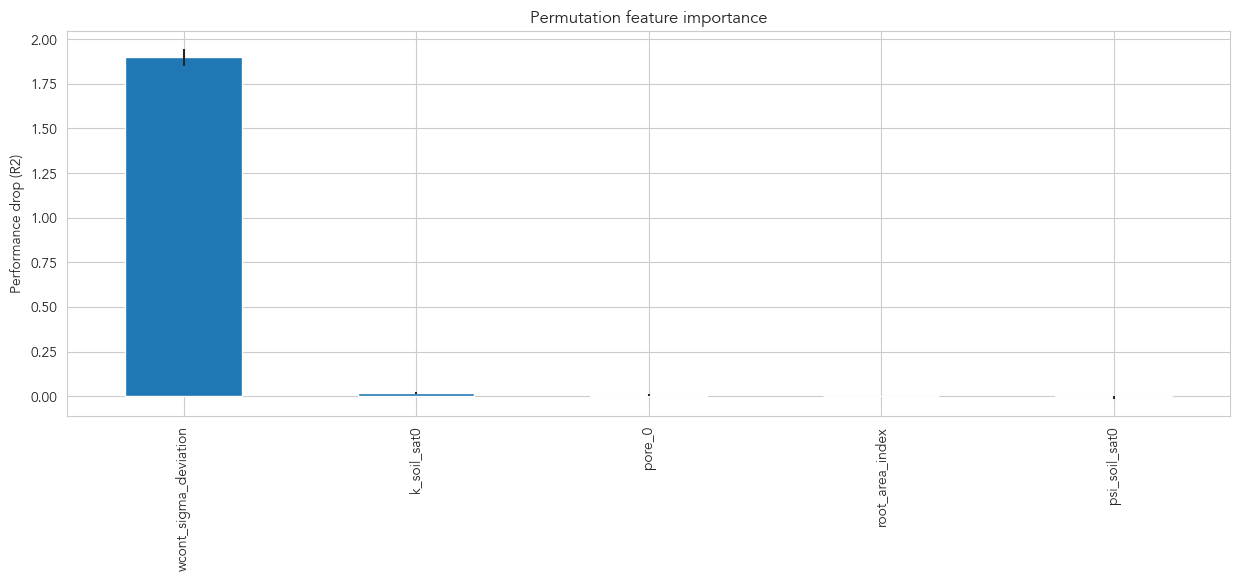

In [38]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,  # we use the test set
    y_test,
    scoring="r2",  # we can use any metric
    n_repeats=100,
    random_state=0,
)
importance = pd.DataFrame(
    {"importance_mean": perm["importances_mean"],
     "importance_std": perm["importances_std"]},
    index=rf.feature_names_in_)
importance["importance_mean"].sort_values(
    ascending=False
).plot(figsize=(15, 5), kind="bar", yerr=importance["importance_std"])
plt.title("Permutation feature importance")
plt.ylabel("Performance drop (R2)")
plt.show()

In [39]:
import shap
shap.initjs()

In [40]:
X_train

,k_soil_sat0,psi_soil_sat0,pore_0,root_area_index,wcont_sigma_deviation
1082,-0.881872,0.611356,0.962990,2.346939,-0.068170
11279,-0.537306,-1.662586,-1.558287,0.109549,-1.114607
6784,0.888461,0.700532,-0.668953,0.578388,-1.083497
5752,1.175157,-0.587612,0.504720,2.366431,-1.118338
9569,-1.082421,0.100626,1.032691,0.630574,-1.241155
...,...,...,...,...,...
2717,-0.972797,0.285197,1.179296,-0.265612,0.430818
5551,-1.128315,1.199497,1.252750,1.360437,-0.094655
11974,0.026378,-1.636078,1.148487,-1.789486,-0.613732
6622,-0.807489,0.621057,0.728809,0.238541,0.520968


In [41]:
X_train.shape

(4312, 5)

In [42]:
explainer = shap.Explainer(rf)
shap_values = explainer(X_train)

In [43]:
shap_values[0,0,:]

.values =
array([ 0.03405406, -0.03405406])

.base_values =
array([0.4995291, 0.5004709])

.data =
-0.8818718983741277

In [44]:
np.shape(shap_values.values)

(4312, 5, 2)

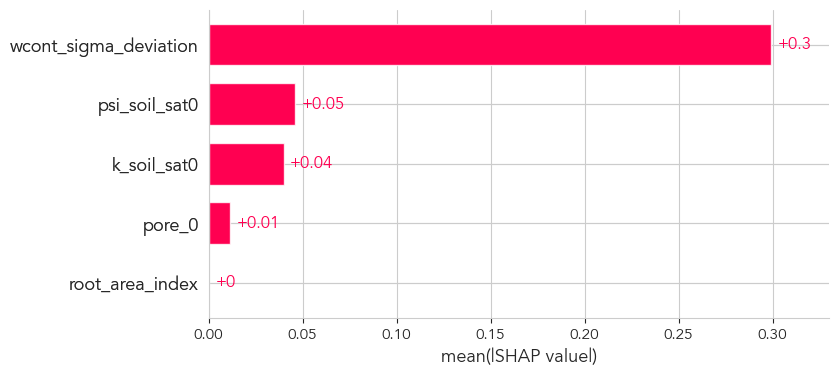

In [45]:
shap.plots.bar(shap_values[:,:,0])

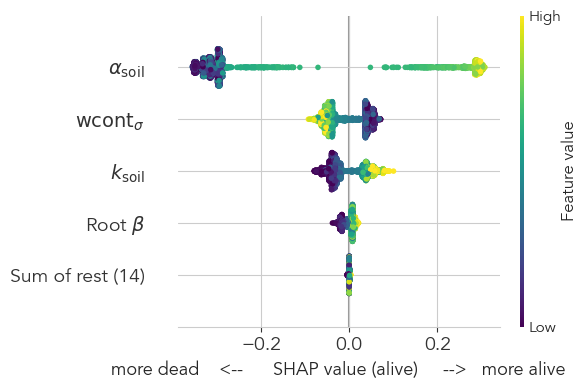

In [46]:

fig = plt.figure(figsize=(8, 6))
labs =list(reversed([r"$\alpha_\mathrm{soil}$",  r"$\mathrm{wcont}_\sigma$", r"$k_\mathrm{soil}$", r"Root $\beta$", "Sum of rest (14)"]))
# print(labs)
import matplotlib as mpl
plt.rcParams["font.family"] = "Avenir"
shap.plots.beeswarm(shap_values[:,:,1], color="viridis", max_display=5, show = False, plot_size=[6,4])
ax = plt.gca()
ax.set_xlabel("more dead    <--      SHAP value (alive)     -->   more alive")
ax.set_yticklabels(labs)
ax.tick_params(labelsize=14)
plt.tight_layout()
plt.savefig(os.path.join(post_path, 'Fig2_shap_ALL.png'), dpi = 300)
plt.show()

In [47]:
vars_all

['psi_leaf_50_close',
 'd_50_close',
 'stem_hydraulic_capacitance',
 'k_xylem_sat',
 'huber_value',
 'leaf_hydraulic_capacitance',
 'psi50_xylem',
 'psi88_xylem',
 'g0',
 'g1',
 'k_soil_sat0',
 'psi_soil_sat0',
 'jackson_root_beta',
 'pore_0',
 'anet_max',
 'root_area_index',
 'wcont_sigma_deviation',
 'g_bark']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(df_grp[vars_all], df_grp['RMSE_MAX'], test_size=0.3, random_state=42)
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=2909)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, random_state=2909)

In [49]:
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

0.9540248194167957
0.7233483817589603


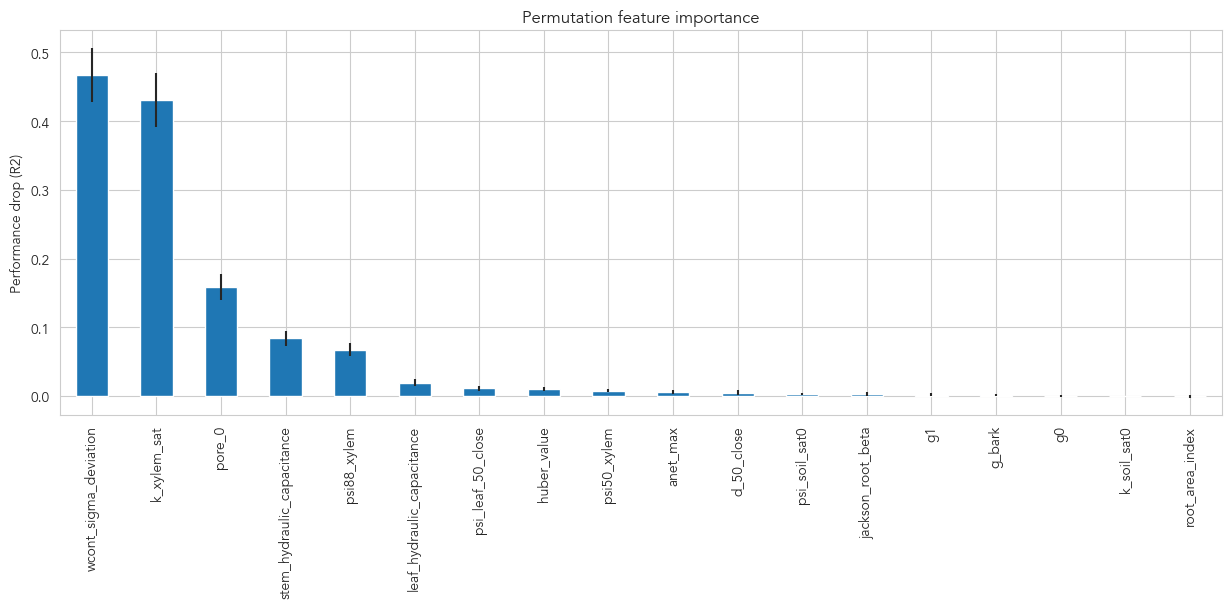

In [50]:
perm = permutation_importance(
    rf,
    X_test,  # we use the test set
    y_test,
    scoring="r2",  # we can use any metric
    n_repeats=100,
    random_state=0,
)
importance = pd.DataFrame(
    {"importance_mean": perm["importances_mean"],
     "importance_std": perm["importances_std"]},
    index=rf.feature_names_in_)
importance["importance_mean"].sort_values(
    ascending=False
).plot(figsize=(15, 5), kind="bar", yerr=importance["importance_std"])
plt.title("Permutation feature importance")
plt.ylabel("Performance drop (R2)")
plt.show()

In [51]:
explainer = shap.Explainer(rf)
shap_values = explainer(X_train)

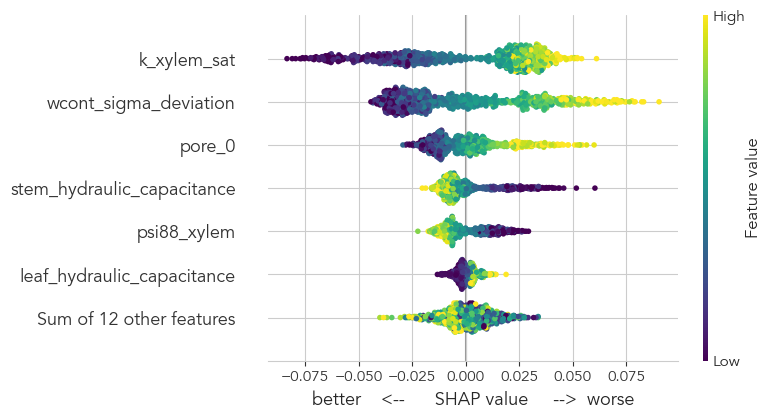

In [52]:
shap.plots.beeswarm(shap_values[:,:], color="viridis", max_display=7, show = False)
ax = plt.gca()
ax.set_xlabel("better    <--      SHAP value     -->  worse")
plt.tight_layout()
#plt.savefig(os.path.join("plt", 'shap_values.png'), dpi = 300)
plt.show()